In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

BASE_DIR = Path("/content/drive/MyDrive/rostat")

SALES_DIR = BASE_DIR / "processed_sales"
MONTHLY_DIR = BASE_DIR / "monthly_forecast"

RESULT_DIR = BASE_DIR / "q2_q3_2022_forecast"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

BASE_DIR = Path("/content/gdrive/MyDrive/rostat")

SALES_DIR = BASE_DIR / "processed_sales"
MONTHLY_DIR = BASE_DIR / "monthly_forecast"

RESULT_DIR = BASE_DIR / "q2_q3_2022_forecast"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

In [44]:
monthly_data = pd.read_csv(
    MONTHLY_DIR / "monthly_price_index_dataset.csv",
    parse_dates=["month_end"]
)

monthly_data = monthly_data.sort_values(
    ["product_group_code", "month_end"]
).reset_index(drop=True)

monthly_data["year"] = monthly_data["month_end"].dt.year
monthly_data["month"] = monthly_data["month_end"].dt.month

price_train_end = pd.Timestamp("2022-03-31")
price_valid_start = pd.Timestamp("2022-04-30")
price_valid_end = pd.Timestamp("2022-09-30")

print("Период месячных данных:")
print(monthly_data["month_end"].min(), "—", monthly_data["month_end"].max())
print("Категорий:", monthly_data["product_group_code"].nunique())

Период месячных данных:
2016-01-31 00:00:00 — 2025-12-31 00:00:00
Категорий: 9


In [45]:
price_sarima_configs_2022 = [
    {
        "model": "SARIMA (0,1,0)(0,1,0,12)",
        "model_type": "SARIMA",
        "component_test": "только дифференцирование и сезонность",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 0, 12)
    },
    {
        "model": "SARIMA (0,1,1)(0,1,0,12)",
        "model_type": "SARIMA",
        "component_test": "добавлена MA-компонента",
        "order": (0, 1, 1),
        "seasonal_order": (0, 1, 0, 12)
    },
    {
        "model": "SARIMA (1,1,0)(0,1,0,12)",
        "model_type": "SARIMA",
        "component_test": "добавлена AR-компонента",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 0, 12)
    },
    {
        "model": "SARIMA (0,1,0)(0,1,1,12)",
        "model_type": "SARIMA",
        "component_test": "добавлена сезонная MA-компонента",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 1, 12)
    },
    {
        "model": "SARIMA (0,1,1)(0,1,1,12)",
        "model_type": "SARIMA",
        "component_test": "MA + сезонная MA",
        "order": (0, 1, 1),
        "seasonal_order": (0, 1, 1, 12)
    },
    {
        "model": "SARIMA (1,1,0)(0,1,1,12)",
        "model_type": "SARIMA",
        "component_test": "AR + сезонная MA",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 1, 12)
    }
]

In [46]:
def run_price_q2_q3_2022_seasonal_naive(category_df, y_col="price_index"):
    df = category_df.copy().sort_values("month_end").reset_index(drop=True)

    train_df = df[df["month_end"] <= price_train_end].copy()
    valid_df = df[
        (df["month_end"] >= price_valid_start) &
        (df["month_end"] <= price_valid_end)
    ].copy()

    assert train_df["month_end"].max() <= price_train_end, (
        "Ошибка: II–III квартал 2022 попал в train"
    )

    if len(valid_df) != 6:
        raise ValueError("Для II–III квартала 2022 должно быть 6 месяцев validation")

    previous_year = train_df[train_df["year"] == 2021].copy()

    yhat = []

    for _, row in valid_df.iterrows():
        prev_value = previous_year.loc[
            previous_year["month"] == row["month"],
            y_col
        ]

        if len(prev_value) == 0:
            raise ValueError(f"Нет значения за месяц {row['month']} в 2021 году")

        yhat.append(float(prev_value.iloc[0]))

    pred = valid_df[
        [
            "month_end",
            "year",
            "month",
            "product_group_code",
            "product_group_name",
            y_col,
            "is_imputed"
        ]
    ].copy()

    pred["y"] = pred[y_col]
    pred["yhat"] = yhat
    pred["model"] = "Seasonal Naive"
    pred["model_type"] = "Seasonal Naive"
    pred["component_test"] = "значение того же месяца прошлого года"

    metrics = calculate_metrics(pred["y"], pred["yhat"])

    metrics.update({
        "target": "price_index",
        "model": "Seasonal Naive",
        "model_type": "Seasonal Naive",
        "component_test": "значение того же месяца прошлого года",
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "train_start": train_df["month_end"].min(),
        "train_end": train_df["month_end"].max(),
        "valid_start": valid_df["month_end"].min(),
        "valid_end": valid_df["month_end"].max(),
        "train_n": len(train_df),
        "valid_n": len(valid_df),
        "train_imputed_points": int(train_df["is_imputed"].sum()),
        "valid_imputed_points": int(valid_df["is_imputed"].sum()),
        "AIC": np.nan,
        "BIC": np.nan
    })

    return pred, metrics

In [47]:
def run_price_q2_q3_2022_sarima(category_df, config, y_col="price_index"):
    df = category_df.copy().sort_values("month_end").reset_index(drop=True)

    train_df = df[df["month_end"] <= price_train_end].copy()
    valid_df = df[
        (df["month_end"] >= price_valid_start) &
        (df["month_end"] <= price_valid_end)
    ].copy()

    assert train_df["month_end"].max() <= price_train_end, (
        "Ошибка: II–III квартал 2022 попал в train"
    )

    if len(valid_df) != 6:
        raise ValueError("Для II–III квартала 2022 должно быть 6 месяцев validation")

    if len(train_df) < 36:
        raise ValueError("Слишком мало наблюдений для SARIMA")

    y_train = np.log1p(train_df[y_col])
    y_valid = valid_df[y_col].values

    model = SARIMAX(
        y_train,
        order=config["order"],
        seasonal_order=config["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(
        disp=False,
        maxiter=300
    )

    forecast_log = result.forecast(steps=len(valid_df))

    yhat = np.expm1(forecast_log)
    yhat = np.maximum(np.asarray(yhat), 0)

    pred = valid_df[
        [
            "month_end",
            "year",
            "month",
            "product_group_code",
            "product_group_name",
            y_col,
            "is_imputed"
        ]
    ].copy()

    pred["y"] = y_valid
    pred["yhat"] = yhat
    pred["model"] = config["model"]
    pred["model_type"] = config["model_type"]
    pred["component_test"] = config["component_test"]

    metrics = calculate_metrics(pred["y"], pred["yhat"])

    metrics.update({
        "target": "price_index",
        "model": config["model"],
        "model_type": config["model_type"],
        "component_test": config["component_test"],
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "train_start": train_df["month_end"].min(),
        "train_end": train_df["month_end"].max(),
        "valid_start": valid_df["month_end"].min(),
        "valid_end": valid_df["month_end"].max(),
        "train_n": len(train_df),
        "valid_n": len(valid_df),
        "train_imputed_points": int(train_df["is_imputed"].sum()),
        "valid_imputed_points": int(valid_df["is_imputed"].sum()),
        "AIC": result.aic,
        "BIC": result.bic
    })

    return result, pred, metrics

In [48]:
price_2022_metrics = []
price_2022_predictions = []
price_2022_models = {}

for group_code, category_df in monthly_data.groupby("product_group_code"):
    group_name = category_df["product_group_name"].iloc[0]

    print("=" * 100)
    print(f"ЦЕНЫ 2022 Q2–Q3 | Категория: {group_code} — {group_name}")

    category_df = category_df.sort_values("month_end").copy()

    try:
        pred, metrics = run_price_q2_q3_2022_seasonal_naive(category_df)

        price_2022_predictions.append(pred)
        price_2022_metrics.append(metrics)

        print(f"Seasonal Naive | MAPE={metrics['MAPE']:.3f}, sMAPE={metrics['sMAPE']:.3f}")

    except Exception as e:
        print("Ошибка Seasonal Naive:", e)

    for config in price_sarima_configs_2022:
        try:
            result, pred, metrics = run_price_q2_q3_2022_sarima(
                category_df,
                config=config
            )

            price_2022_predictions.append(pred)
            price_2022_metrics.append(metrics)

            price_2022_models[f"{group_code}_{config['model']}"] = result

            print(f"{config['model']} | MAPE={metrics['MAPE']:.3f}, sMAPE={metrics['sMAPE']:.3f}")

        except Exception as e:
            print(f"Ошибка {config['model']}: {e}")

price_2022_metrics_df = pd.DataFrame(price_2022_metrics)
price_2022_predictions_df = pd.concat(price_2022_predictions, ignore_index=True)

ЦЕНЫ 2022 Q2–Q3 | Категория: G01 — Хлеб, крупы, мука и макаронные изделия
Seasonal Naive | MAPE=21.642, sMAPE=24.284
SARIMA (0,1,0)(0,1,0,12) | MAPE=6.238, sMAPE=6.456
SARIMA (0,1,1)(0,1,0,12) | MAPE=3.942, sMAPE=4.039
SARIMA (1,1,0)(0,1,0,12) | MAPE=4.135, sMAPE=4.051
SARIMA (0,1,0)(0,1,1,12) | MAPE=6.756, sMAPE=6.997
SARIMA (0,1,1)(0,1,1,12) | MAPE=4.274, sMAPE=4.372
SARIMA (1,1,0)(0,1,1,12) | MAPE=3.818, sMAPE=3.736
ЦЕНЫ 2022 Q2–Q3 | Категория: G02 — Молочная продукция и яйца
Seasonal Naive | MAPE=11.538, sMAPE=12.278
SARIMA (0,1,0)(0,1,0,12) | MAPE=2.475, sMAPE=2.481
SARIMA (0,1,1)(0,1,0,12) | MAPE=2.501, sMAPE=2.481
SARIMA (1,1,0)(0,1,0,12) | MAPE=2.898, sMAPE=2.864
SARIMA (0,1,0)(0,1,1,12) | MAPE=2.294, sMAPE=2.331
SARIMA (0,1,1)(0,1,1,12) | MAPE=1.722, sMAPE=1.744
SARIMA (1,1,0)(0,1,1,12) | MAPE=1.587, sMAPE=1.603
ЦЕНЫ 2022 Q2–Q3 | Категория: G03 — Мясо, птица, рыба и колбасные изделия
Seasonal Naive | MAPE=15.000, sMAPE=16.223
SARIMA (0,1,0)(0,1,0,12) | MAPE=2.899, sMAPE=2.949


In [49]:
best_price_2022_by_category = (
    price_2022_metrics_df
    .sort_values(["product_group_code", "MAPE"])
    .groupby("product_group_code")
    .head(1)
    .reset_index(drop=True)
)

best_price_2022_predictions = price_2022_predictions_df.merge(
    best_price_2022_by_category[["product_group_code", "model"]],
    on=["product_group_code", "model"],
    how="inner"
).sort_values(["product_group_code", "month_end"]).reset_index(drop=True)

display(
    best_price_2022_by_category[
        [
            "product_group_code",
            "product_group_name",
            "model",
            "component_test",
            "MAE",
            "RMSE",
            "MAPE",
            "sMAPE",
            "train_start",
            "train_end",
            "valid_start",
            "valid_end",
            "train_imputed_points",
            "valid_imputed_points"
        ]
    ].round(3)
)

,product_group_code,product_group_name,model,component_test,MAE,RMSE,MAPE,sMAPE,train_start,train_end,valid_start,valid_end,train_imputed_points,valid_imputed_points
0,G01,"Хлеб, крупы, мука и макаронные изделия","SARIMA (1,1,0)(0,1,1,12)",AR + сезонная MA,6.405,7.428,3.818,3.736,2016-01-31,2022-03-31,2022-04-30,2022-09-30,12,0
1,G02,Молочная продукция и яйца,"SARIMA (1,1,0)(0,1,1,12)",AR + сезонная MA,2.401,2.814,1.587,1.603,2016-01-31,2022-03-31,2022-04-30,2022-09-30,12,0
2,G03,"Мясо, птица, рыба и колбасные изделия","SARIMA (1,1,0)(0,1,1,12)",AR + сезонная MA,2.593,3.049,1.769,1.790,2016-01-31,2022-03-31,2022-04-30,2022-09-30,12,0
3,G04,"Овощи, фрукты и картофель",Seasonal Naive,значение того же месяца прошлого года,74.935,93.647,32.825,39.572,2016-01-31,2022-03-31,2022-04-30,2022-09-30,12,0
4,G05,"Бакалея, масло, сахар, чай, соль","SARIMA (1,1,0)(0,1,0,12)",добавлена AR-компонента,7.095,9.497,3.711,3.600,2016-01-31,2022-03-31,2022-04-30,2022-09-30,12,0
5,G07,"Товары для дома, гигиены и бытовая химия","SARIMA (1,1,0)(0,1,0,12)",добавлена AR-компонента,24.152,24.291,15.177,16.435,2016-01-31,2022-03-31,2022-04-30,2022-09-30,12,0
6,G10,Топливо и транспортные товары,"SARIMA (0,1,1)(0,1,0,12)",добавлена MA-компонента,3.467,3.933,2.401,2.365,2016-01-31,2022-03-31,2022-04-30,2022-09-30,12,0
7,G11,Услуги,"SARIMA (1,1,0)(0,1,1,12)",AR + сезонная MA,0.723,0.875,0.469,0.468,2016-01-31,2022-03-31,2022-04-30,2022-09-30,12,0
8,G99,Прочее,"SARIMA (0,1,0)(0,1,1,12)",добавлена сезонная MA-компонента,2.169,2.702,1.558,1.576,2016-01-31,2022-03-31,2022-04-30,2022-09-30,12,0


In [50]:
arimax_data = pd.read_csv(
    SALES_DIR / "arimax_category_dataset.csv",
    parse_dates=["period_end"]
)

arimax_data = arimax_data.sort_values(
    ["product_group_code", "period_end"]
).reset_index(drop=True)

arimax_data["year"] = arimax_data["period_end"].dt.year
arimax_data["quarter"] = arimax_data["period_end"].dt.quarter

if "is_imputed" in arimax_data.columns:
    arimax_data["is_imputed"] = arimax_data["is_imputed"].astype(bool)
else:
    arimax_data["is_imputed"] = False

arimax_data["price_index_lag4"] = (
    arimax_data
    .groupby("product_group_code")["price_index"]
    .shift(4)
)

sales_train_end = pd.Timestamp("2022-03-31")
sales_valid_start = pd.Timestamp("2022-06-30")
sales_valid_end = pd.Timestamp("2022-09-30")

print("Период квартальных данных:")
print(arimax_data["period_end"].min(), "—", arimax_data["period_end"].max())
print("Категорий:", arimax_data["product_group_code"].nunique())

Период квартальных данных:
2017-03-31 00:00:00 — 2025-12-31 00:00:00
Категорий: 8


In [51]:
sales_configs_2022 = [
    {
        "model": "SARIMA (0,1,0)(0,1,0,4)",
        "model_type": "SARIMA",
        "component_test": "только дифференцирование и квартальная сезонность",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 0, 4),
        "exog_cols": []
    },
    {
        "model": "SARIMA (0,1,0)(0,1,1,4)",
        "model_type": "SARIMA",
        "component_test": "добавлена сезонная MA-компонента",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 1, 4),
        "exog_cols": []
    },
    {
        "model": "SARIMA (1,1,0)(0,1,0,4)",
        "model_type": "SARIMA",
        "component_test": "добавлена AR-компонента",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 0, 4),
        "exog_cols": []
    },
    {
        "model": "SARIMA (1,1,0)(0,1,1,4)",
        "model_type": "SARIMA",
        "component_test": "AR + сезонная MA",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 1, 4),
        "exog_cols": []
    },
    {
        "model": "SARIMAX (0,1,0)(0,1,0,4) + price_index_lag4",
        "model_type": "SARIMAX",
        "component_test": "лаг цены аналогичного квартала прошлого года",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 0, 4),
        "exog_cols": ["price_index_lag4"]
    },
    {
        "model": "SARIMAX (1,1,0)(0,1,0,4) + price_index_lag4",
        "model_type": "SARIMAX",
        "component_test": "AR + лаг цены аналогичного квартала прошлого года",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 0, 4),
        "exog_cols": ["price_index_lag4"]
    }
]

In [52]:
def run_sales_q2_q3_2022_seasonal_naive(category_df, y_col="sales_index"):
    df = category_df.copy().sort_values("period_end").reset_index(drop=True)

    train_df = df[df["period_end"] <= sales_train_end].copy()
    valid_df = df[
        (df["period_end"] >= sales_valid_start) &
        (df["period_end"] <= sales_valid_end)
    ].copy()

    assert train_df["period_end"].max() <= sales_train_end, (
        "Ошибка: II–III квартал 2022 попал в train"
    )

    if len(valid_df) != 2:
        raise ValueError("Для II–III квартала 2022 должно быть 2 validation-точки")

    yhat = []

    for _, row in valid_df.iterrows():
        prev_value = train_df.loc[
            (train_df["year"] == row["year"] - 1) &
            (train_df["quarter"] == row["quarter"]),
            y_col
        ]

        if len(prev_value) == 0:
            raise ValueError(f"Нет значения за {row['year'] - 1}Q{row['quarter']}")

        yhat.append(float(prev_value.iloc[0]))

    pred = valid_df[
        [
            "period_end",
            "year",
            "quarter",
            "product_group_code",
            "product_group_name",
            y_col,
            "is_imputed"
        ]
    ].copy()

    pred["y"] = pred[y_col]
    pred["yhat"] = yhat
    pred["model"] = "Seasonal Naive"
    pred["model_type"] = "Seasonal Naive"
    pred["component_test"] = "значение аналогичного квартала прошлого года"

    metrics = calculate_metrics(pred["y"], pred["yhat"])

    metrics.update({
        "target": "sales_index",
        "model": "Seasonal Naive",
        "model_type": "Seasonal Naive",
        "component_test": "значение аналогичного квартала прошлого года",
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "train_start": train_df["period_end"].min(),
        "train_end": train_df["period_end"].max(),
        "valid_start": valid_df["period_end"].min(),
        "valid_end": valid_df["period_end"].max(),
        "train_n": len(train_df),
        "valid_n": len(valid_df),
        "train_imputed_points": int(train_df["is_imputed"].sum()),
        "valid_imputed_points": int(valid_df["is_imputed"].sum()),
        "AIC": np.nan,
        "BIC": np.nan
    })

    return pred, metrics

In [53]:
def run_sales_q2_q3_2022_sarimax(category_df, config, y_col="sales_index"):
    df = category_df.copy().sort_values("period_end").reset_index(drop=True)

    train_df = df[df["period_end"] <= sales_train_end].copy()
    valid_df = df[
        (df["period_end"] >= sales_valid_start) &
        (df["period_end"] <= sales_valid_end)
    ].copy()

    assert train_df["period_end"].max() <= sales_train_end, (
        "Ошибка: II–III квартал 2022 попал в train"
    )

    if len(valid_df) != 2:
        raise ValueError("Для II–III квартала 2022 должно быть 2 validation-точки")

    exog_cols = config["exog_cols"]
    needed_cols = [y_col] + exog_cols

    train_df = train_df.dropna(subset=needed_cols).copy()
    valid_df = valid_df.dropna(subset=needed_cols).copy()

    if len(valid_df) != 2:
        raise ValueError("После удаления NaN нет двух validation-точек")

    if len(train_df) < 12:
        raise ValueError("Слишком мало train-наблюдений")

    y_train = np.log1p(train_df[y_col])
    y_valid = valid_df[y_col].values

    if len(exog_cols) > 0:
        exog_train = train_df[exog_cols].copy()
        exog_valid = valid_df[exog_cols].copy()

        exog_mean = exog_train.mean()
        exog_std = exog_train.std().replace(0, 1)

        exog_train_scaled = (exog_train - exog_mean) / exog_std
        exog_valid_scaled = (exog_valid - exog_mean) / exog_std
    else:
        exog_train_scaled = None
        exog_valid_scaled = None

    model = SARIMAX(
        y_train,
        exog=exog_train_scaled,
        order=config["order"],
        seasonal_order=config["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(
        disp=False,
        maxiter=300
    )

    forecast_log = result.forecast(
        steps=len(valid_df),
        exog=exog_valid_scaled
    )

    yhat = np.expm1(forecast_log)
    yhat = np.maximum(np.asarray(yhat), 0)

    pred = valid_df[
        [
            "period_end",
            "year",
            "quarter",
            "product_group_code",
            "product_group_name",
            y_col,
            "is_imputed"
        ]
    ].copy()

    pred["y"] = y_valid
    pred["yhat"] = yhat
    pred["model"] = config["model"]
    pred["model_type"] = config["model_type"]
    pred["component_test"] = config["component_test"]

    metrics = calculate_metrics(pred["y"], pred["yhat"])

    metrics.update({
        "target": "sales_index",
        "model": config["model"],
        "model_type": config["model_type"],
        "component_test": config["component_test"],
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "train_start": train_df["period_end"].min(),
        "train_end": train_df["period_end"].max(),
        "valid_start": valid_df["period_end"].min(),
        "valid_end": valid_df["period_end"].max(),
        "train_n": len(train_df),
        "valid_n": len(valid_df),
        "train_imputed_points": int(train_df["is_imputed"].sum()),
        "valid_imputed_points": int(valid_df["is_imputed"].sum()),
        "AIC": result.aic,
        "BIC": result.bic
    })

    return result, pred, metrics

In [54]:
sales_2022_metrics = []
sales_2022_predictions = []
sales_2022_models = {}

for group_code, category_df in arimax_data.groupby("product_group_code"):
    group_name = category_df["product_group_name"].iloc[0]

    print("=" * 100)
    print(f"ПРОДАЖИ 2022 Q2–Q3 | Категория: {group_code} — {group_name}")

    category_df = category_df.sort_values("period_end").copy()

    try:
        pred, metrics = run_sales_q2_q3_2022_seasonal_naive(category_df)

        sales_2022_predictions.append(pred)
        sales_2022_metrics.append(metrics)

        print(f"Seasonal Naive | MAPE={metrics['MAPE']:.3f}, sMAPE={metrics['sMAPE']:.3f}")

    except Exception as e:
        print("Ошибка Seasonal Naive:", e)

    for config in sales_configs_2022:
        try:
            result, pred, metrics = run_sales_q2_q3_2022_sarimax(
                category_df,
                config=config
            )

            sales_2022_predictions.append(pred)
            sales_2022_metrics.append(metrics)

            sales_2022_models[f"{group_code}_{config['model']}"] = result

            print(f"{config['model']} | MAPE={metrics['MAPE']:.3f}, sMAPE={metrics['sMAPE']:.3f}")

        except Exception as e:
            print(f"Ошибка {config['model']}: {e}")

sales_2022_metrics_df = pd.DataFrame(sales_2022_metrics)
sales_2022_predictions_df = pd.concat(sales_2022_predictions, ignore_index=True)

ПРОДАЖИ 2022 Q2–Q3 | Категория: G01 — Хлеб, крупы, мука и макаронные изделия
Seasonal Naive | MAPE=12.415, sMAPE=13.817
SARIMA (0,1,0)(0,1,0,4) | MAPE=10.190, sMAPE=11.169
SARIMA (0,1,0)(0,1,1,4) | MAPE=10.190, sMAPE=11.169
SARIMA (1,1,0)(0,1,0,4) | MAPE=10.194, sMAPE=11.172
SARIMA (1,1,0)(0,1,1,4) | MAPE=10.194, sMAPE=11.172
SARIMAX (0,1,0)(0,1,0,4) + price_index_lag4 | MAPE=10.278, sMAPE=11.149
SARIMAX (1,1,0)(0,1,0,4) + price_index_lag4 | MAPE=10.143, sMAPE=10.988
ПРОДАЖИ 2022 Q2–Q3 | Категория: G02 — Молочная продукция и яйца
Seasonal Naive | MAPE=12.468, sMAPE=13.819
SARIMA (0,1,0)(0,1,0,4) | MAPE=10.808, sMAPE=10.615
SARIMA (0,1,0)(0,1,1,4) | MAPE=10.808, sMAPE=10.615
SARIMA (1,1,0)(0,1,0,4) | MAPE=10.828, sMAPE=10.624
SARIMA (1,1,0)(0,1,1,4) | MAPE=10.828, sMAPE=10.624
SARIMAX (0,1,0)(0,1,0,4) + price_index_lag4 | MAPE=8.078, sMAPE=7.541
SARIMAX (1,1,0)(0,1,0,4) + price_index_lag4 | MAPE=7.999, sMAPE=7.455
ПРОДАЖИ 2022 Q2–Q3 | Категория: G03 — Мясо, птица, рыба и колбасные издел

In [66]:
best_sales_2022_by_category = (
    sales_2022_metrics_df
    .sort_values(["product_group_code", "MAPE"])
    .groupby("product_group_code")
    .head(1)
    .reset_index(drop=True)
)

best_sales_2022_predictions = sales_2022_predictions_df.merge(
    best_sales_2022_by_category[["product_group_code", "model"]],
    on=["product_group_code", "model"],
    how="inner"
).sort_values(["product_group_code", "period_end"]).reset_index(drop=True)

display(
    best_sales_2022_by_category[
        [
            "product_group_code",
            "product_group_name",
            "model_type",
            "MAE",
            "RMSE",
            "MAPE",
            "sMAPE",
            "train_imputed_points",
            "valid_imputed_points"
        ]
    ].round(3)
)

,product_group_code,product_group_name,model_type,MAE,RMSE,MAPE,sMAPE,train_imputed_points,valid_imputed_points
0,G01,"Хлеб, крупы, мука и макаронные изделия",SARIMAX,18.134,23.155,10.143,10.988,4,0
1,G02,Молочная продукция и яйца,SARIMAX,10.678,14.270,7.999,7.455,4,0
2,G03,"Мясо, птица, рыба и колбасные изделия",SARIMA,9.514,11.601,6.324,6.603,4,0
3,G04,"Овощи, фрукты и картофель",SARIMAX,12.222,14.444,6.401,6.695,4,0
4,G05,"Бакалея, масло, сахар, чай, соль",SARIMA,20.009,24.894,11.103,12.111,4,0
5,G07,"Товары для дома, гигиены и бытовая химия",SARIMAX,10.878,15.002,4.902,5.140,4,0
6,G10,Топливо и транспортные товары,SARIMAX,7.507,8.204,7.497,7.248,4,0
7,G99,Прочее,SARIMAX,7.723,10.450,4.527,4.719,4,0


In [56]:
price_leak_check_2022 = price_2022_metrics_df.copy()

price_leak_check_2022["train_end"] = pd.to_datetime(price_leak_check_2022["train_end"])
price_leak_check_2022["valid_start"] = pd.to_datetime(price_leak_check_2022["valid_start"])
price_leak_check_2022["valid_end"] = pd.to_datetime(price_leak_check_2022["valid_end"])

price_leak_check_2022["train_uses_q2_q3_2022"] = (
    price_leak_check_2022["train_end"] >= pd.Timestamp("2022-04-01")
)

price_leak_check_2022["validation_is_q2_q3_2022"] = (
    (price_leak_check_2022["valid_start"] == pd.Timestamp("2022-04-30")) &
    (price_leak_check_2022["valid_end"] == pd.Timestamp("2022-09-30"))
)

print("Цены: есть ли обучение на II–III кварталах 2022?")
print(price_leak_check_2022["train_uses_q2_q3_2022"].any())

print("Цены: у всех validation именно апрель–сентябрь 2022?")
print(price_leak_check_2022["validation_is_q2_q3_2022"].all())

Цены: есть ли обучение на II–III кварталах 2022?
False
Цены: у всех validation именно апрель–сентябрь 2022?
True


In [64]:
price_2022_model_summary = (
    price_2022_metrics_df
    .groupby(["target", "model_type", "model", "component_test"], as_index=False)
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_MAPE=("MAPE", "mean"),
        mean_sMAPE=("sMAPE", "mean"),
        std_MAPE=("MAPE", "std"),
        min_MAPE=("MAPE", "min"),
        max_MAPE=("MAPE", "max"),
        n_categories=("product_group_code", "nunique")
    )
    .sort_values("mean_MAPE")
)

sales_2022_model_summary = (
    sales_2022_metrics_df
    .groupby(["target", "model_type"], as_index=False)
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_MAPE=("MAPE", "mean"),
        mean_sMAPE=("sMAPE", "mean"),
        std_MAPE=("MAPE", "std"),
        min_MAPE=("MAPE", "min"),
        max_MAPE=("MAPE", "max"),
        n_categories=("product_group_code", "nunique")
    )
    .sort_values("mean_MAPE")
)

print("Сводка по прогнозу цен на II–III кварталы 2022:")
display(price_2022_model_summary.round(3))

print("Сводка по прогнозу индекса продаж за II–III кварталы 2022:")
display(sales_2022_model_summary.round(3))

Сводка по прогнозу цен на II–III кварталы 2022:


,target,model_type,model,component_test,mean_MAE,mean_RMSE,mean_MAPE,mean_sMAPE,std_MAPE,min_MAPE,max_MAPE,n_categories
3,price_index,SARIMA,"SARIMA (0,1,1)(0,1,1,12)",MA + сезонная MA,16.339,17.659,9.966,8.565,17.156,0.487,53.857,9
2,price_index,SARIMA,"SARIMA (0,1,1)(0,1,0,12)",добавлена MA-компонента,16.573,18.976,10.467,8.606,18.456,1.817,58.149,9
4,price_index,SARIMA,"SARIMA (1,1,0)(0,1,0,12)",добавлена AR-компонента,16.844,19.477,10.648,8.508,19.676,1.822,61.901,9
5,price_index,SARIMA,"SARIMA (1,1,0)(0,1,1,12)",AR + сезонная MA,17.622,19.581,10.721,8.851,19.463,0.469,60.863,9
0,price_index,SARIMA,"SARIMA (0,1,0)(0,1,0,12)",только дифференцирование и сезонность,18.145,20.414,11.329,9.711,17.343,1.821,55.460,9
1,price_index,SARIMA,"SARIMA (0,1,0)(0,1,1,12)",добавлена сезонная MA-компонента,19.174,20.553,11.629,10.208,17.832,0.570,56.489,9
6,price_index,Seasonal Naive,Seasonal Naive,значение того же месяца прошлого года,30.519,32.783,17.168,19.534,10.917,4.179,32.825,9


Сводка по прогнозу индекса продаж за II–III кварталы 2022:


,target,model_type,mean_MAE,mean_RMSE,mean_MAPE,mean_sMAPE,std_MAPE,min_MAPE,max_MAPE,n_categories
1,sales_index,SARIMAX,14.125,17.401,8.617,9.058,3.537,4.527,17.335,8
0,sales_index,SARIMA,14.687,17.476,8.944,9.259,2.191,5.830,11.765,8
2,sales_index,Seasonal Naive,22.566,26.056,15.283,14.914,12.068,5.961,44.214,8


In [58]:
best_price_2022_summary = pd.DataFrame([{
    "target": "price_index",
    "period": "2022 Q2–Q3",
    "selection": "best model by category",
    "mean_MAE": best_price_2022_by_category["MAE"].mean(),
    "mean_RMSE": best_price_2022_by_category["RMSE"].mean(),
    "mean_MAPE": best_price_2022_by_category["MAPE"].mean(),
    "mean_sMAPE": best_price_2022_by_category["sMAPE"].mean(),
    "std_MAPE": best_price_2022_by_category["MAPE"].std(),
    "min_MAPE": best_price_2022_by_category["MAPE"].min(),
    "max_MAPE": best_price_2022_by_category["MAPE"].max(),
    "n_categories": best_price_2022_by_category["product_group_code"].nunique()
}])

best_sales_2022_summary = pd.DataFrame([{
    "target": "sales_index",
    "period": "2022 Q2–Q3",
    "selection": "best model by category",
    "mean_MAE": best_sales_2022_by_category["MAE"].mean(),
    "mean_RMSE": best_sales_2022_by_category["RMSE"].mean(),
    "mean_MAPE": best_sales_2022_by_category["MAPE"].mean(),
    "mean_sMAPE": best_sales_2022_by_category["sMAPE"].mean(),
    "std_MAPE": best_sales_2022_by_category["MAPE"].std(),
    "min_MAPE": best_sales_2022_by_category["MAPE"].min(),
    "max_MAPE": best_sales_2022_by_category["MAPE"].max(),
    "n_categories": best_sales_2022_by_category["product_group_code"].nunique()
}])

final_2022_summary = pd.concat(
    [best_price_2022_summary, best_sales_2022_summary],
    ignore_index=True
)

display(final_2022_summary.round(3))

,target,period,selection,mean_MAE,mean_RMSE,mean_MAPE,mean_sMAPE,std_MAPE,min_MAPE,max_MAPE,n_categories
0,price_index,2022 Q2–Q3,best model by category,13.771,16.471,7.035,7.905,10.635,0.469,32.825,9
1,sales_index,2022 Q2–Q3,best model by category,12.083,15.252,7.362,7.620,2.337,4.527,11.103,8


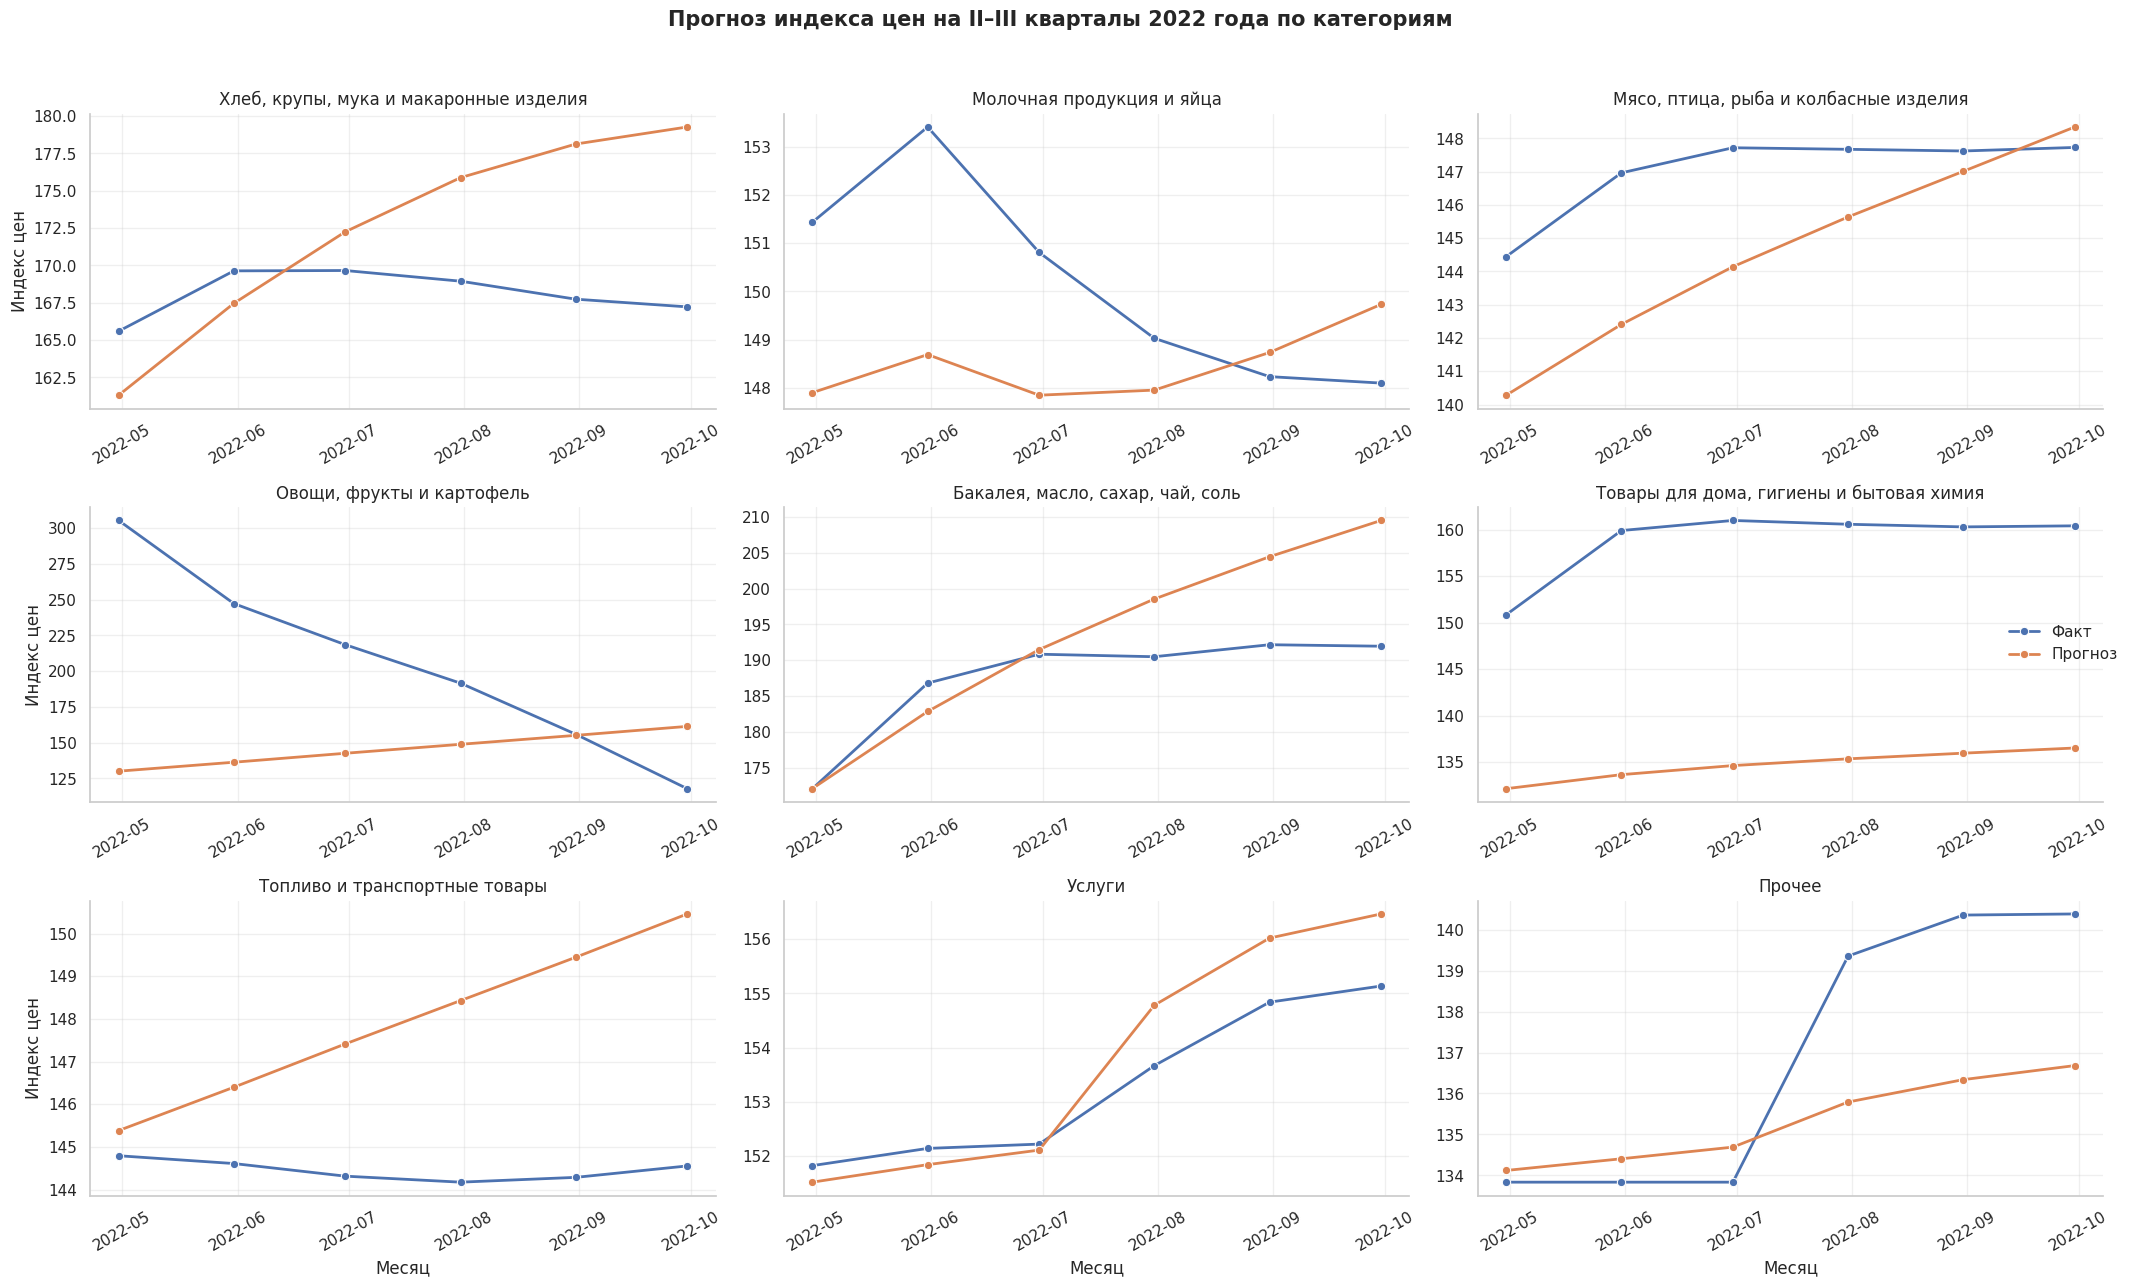

In [59]:
price_2022_plot = pd.concat(
    [
        best_price_2022_predictions[
            ["month_end", "product_group_name", "y"]
        ].rename(columns={"y": "value"}).assign(series="Факт"),
        best_price_2022_predictions[
            ["month_end", "product_group_name", "yhat"]
        ].rename(columns={"yhat": "value"}).assign(series="Прогноз")
    ],
    ignore_index=True
)

g = sns.FacetGrid(
    price_2022_plot,
    col="product_group_name",
    col_wrap=3,
    height=4.2,
    aspect=1.6,
    hue="series",
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="month_end",
    y="value",
    marker="o",
    linewidth=2
)

g.add_legend(title="")
g.set_axis_labels("Месяц", "Индекс цен")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Прогноз индекса цен на II–III кварталы 2022 года по категориям",
    y=1.02,
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

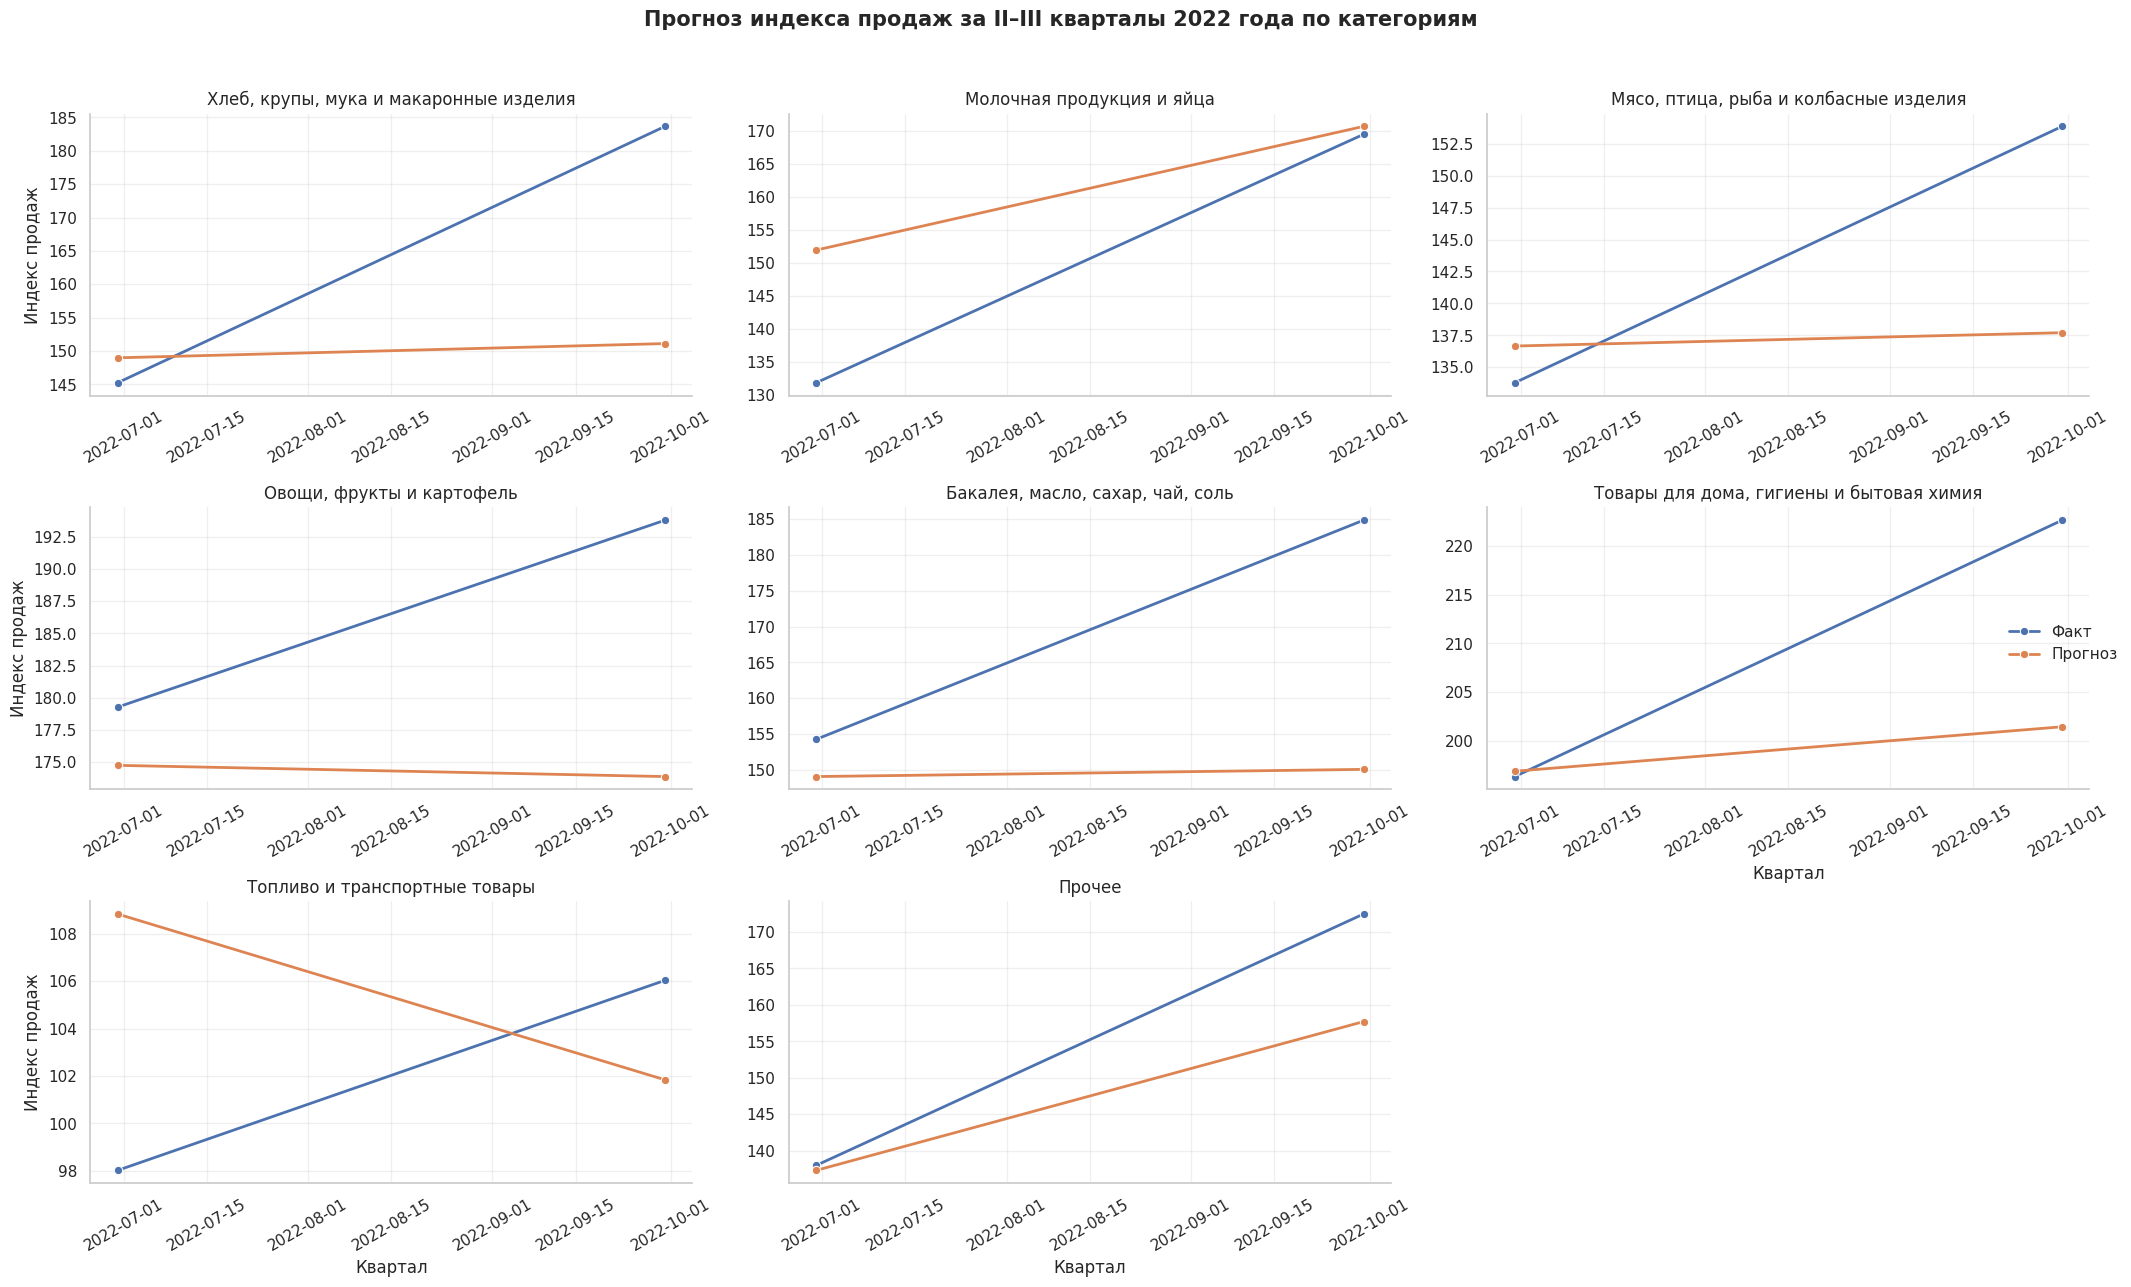

In [60]:
sales_2022_plot = pd.concat(
    [
        best_sales_2022_predictions[
            ["period_end", "product_group_name", "y"]
        ].rename(columns={"y": "value"}).assign(series="Факт"),
        best_sales_2022_predictions[
            ["period_end", "product_group_name", "yhat"]
        ].rename(columns={"yhat": "value"}).assign(series="Прогноз")
    ],
    ignore_index=True
)

g = sns.FacetGrid(
    sales_2022_plot,
    col="product_group_name",
    col_wrap=3,
    height=4.2,
    aspect=1.6,
    hue="series",
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="period_end",
    y="value",
    marker="o",
    linewidth=2
)

g.add_legend(title="")
g.set_axis_labels("Квартал", "Индекс продаж")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Прогноз индекса продаж за II–III кварталы 2022 года по категориям",
    y=1.02,
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [61]:
price_2022_metrics_df.to_csv(
    RESULT_DIR / "price_q2_q3_2022_all_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

price_2022_predictions_df.to_csv(
    RESULT_DIR / "price_q2_q3_2022_all_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

best_price_2022_by_category.to_csv(
    RESULT_DIR / "price_q2_q3_2022_best_by_category.csv",
    index=False,
    encoding="utf-8-sig"
)

best_price_2022_predictions.to_csv(
    RESULT_DIR / "price_q2_q3_2022_best_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

sales_2022_metrics_df.to_csv(
    RESULT_DIR / "sales_q2_q3_2022_all_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

sales_2022_predictions_df.to_csv(
    RESULT_DIR / "sales_q2_q3_2022_all_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

best_sales_2022_by_category.to_csv(
    RESULT_DIR / "sales_q2_q3_2022_best_by_category.csv",
    index=False,
    encoding="utf-8-sig"
)

best_sales_2022_predictions.to_csv(
    RESULT_DIR / "sales_q2_q3_2022_best_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

price_2022_model_summary.to_csv(
    RESULT_DIR / "price_q2_q3_2022_model_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

sales_2022_model_summary.to_csv(
    RESULT_DIR / "sales_q2_q3_2022_model_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

final_2022_summary.to_csv(
    RESULT_DIR / "q2_q3_2022_final_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Файлы сохранены в:", RESULT_DIR)

Файлы сохранены в: /content/gdrive/MyDrive/rostat/q2_q3_2022_forecast


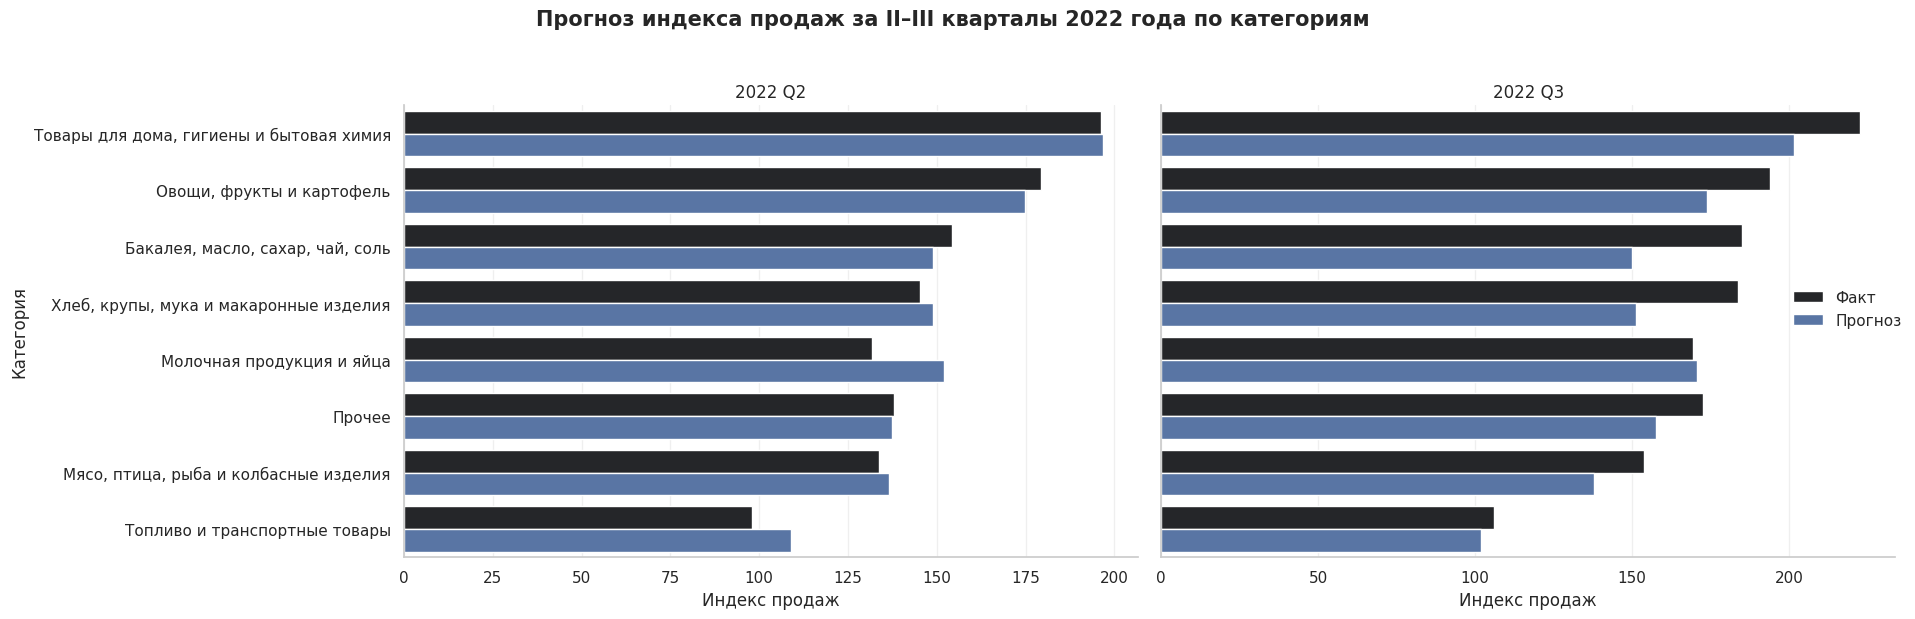

In [62]:
sales_2022_bar = best_sales_2022_predictions.copy()

sales_2022_bar["period_label"] = (
    sales_2022_bar["year"].astype(str)
    + " Q"
    + sales_2022_bar["quarter"].astype(str)
)

sales_2022_bar_plot = pd.concat(
    [
        sales_2022_bar[
            ["period_label", "product_group_name", "y"]
        ].rename(columns={"y": "value"}).assign(series="Факт"),
        sales_2022_bar[
            ["period_label", "product_group_name", "yhat"]
        ].rename(columns={"yhat": "value"}).assign(series="Прогноз")
    ],
    ignore_index=True
)

g = sns.FacetGrid(
    sales_2022_bar_plot,
    col="period_label",
    col_wrap=2,
    height=6,
    aspect=1.5,
    sharex=False,
    sharey=True
)

g.map_dataframe(
    sns.barplot,
    x="value",
    y="product_group_name",
    hue="series",
    order=(
        sales_2022_bar_plot
        .groupby("product_group_name")["value"]
        .mean()
        .sort_values(ascending=False)
        .index
    )
)

g.add_legend(title="")
g.set_axis_labels("Индекс продаж", "Категория")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.grid(axis="x", alpha=0.3)

plt.suptitle(
    "Прогноз индекса продаж за II–III кварталы 2022 года по категориям",
    y=1.03,
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()